# Open and visualize rasters from `466U_100R.zarr`

This notebook opens the zarr tile at
`/Users/roberto.delprete/Downloads/sarpyx/data/insar/validation_tiling/tiles/466U_100R.zarr`
and visualizes its raster bands in a multi-row, multi-column panel.

The zarr store contains geospatial raster layers for one validation tile. Each
panel shows one 2D raster from the tile, using percentile-based `vmin`/`vmax`
scaling so that outliers do not dominate the color contrast.

The interferogram is stored as separate in-phase (`i_ifg_*`) and quadrature
(`q_ifg_*`) components. Instead of plotting those two components separately,
the notebook combines them into interferogram amplitude:

`amplitude = sqrt(i_ifg**2 + q_ifg**2)`

The remaining rasters, such as coherence, elevation, and local incidence angle,
are plotted directly as individual panels.


In [5]:
from __future__ import annotations

import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import zarr


In [6]:
zarr_path = Path('/Users/roberto.delprete/Downloads/sarpyx/data/insar/validation_tiling/tiles/466U_100R.zarr')
store = zarr.open(zarr_path, mode='r')

print('Store loaded:', zarr_path)


Store loaded: /Users/roberto.delprete/Downloads/sarpyx/data/insar/validation_tiling/tiles/466U_100R.zarr


In [7]:
raster_arrays = []

def collect_arrays(node, prefix=''):
    for arr_name in sorted(node.array_keys()):
        raster_arrays.append((f'{prefix}{arr_name}', node[arr_name]))

    for group_name in sorted(node.group_keys()):
        collect_arrays(node[group_name], prefix=f'{prefix}{group_name}/')

collect_arrays(store)

if not raster_arrays:
    raise ValueError(f'No arrays found in {zarr_path}')

print(f'Found {len(raster_arrays)} raster(s):')
for name, arr in raster_arrays:
    print(f' - {name}: {arr.shape} ({arr.dtype})')


Found 5 raster(s):
 - bands/coh_IW2_VV_17Feb2025_05Feb2025: (1000, 1000) (float32)
 - bands/elevation: (1000, 1000) (float32)
 - bands/i_ifg_VV_17Feb2025_05Feb2025: (1000, 1000) (float32)
 - bands/localIncidenceAngle: (1000, 1000) (float32)
 - bands/q_ifg_VV_17Feb2025_05Feb2025: (1000, 1000) (float32)


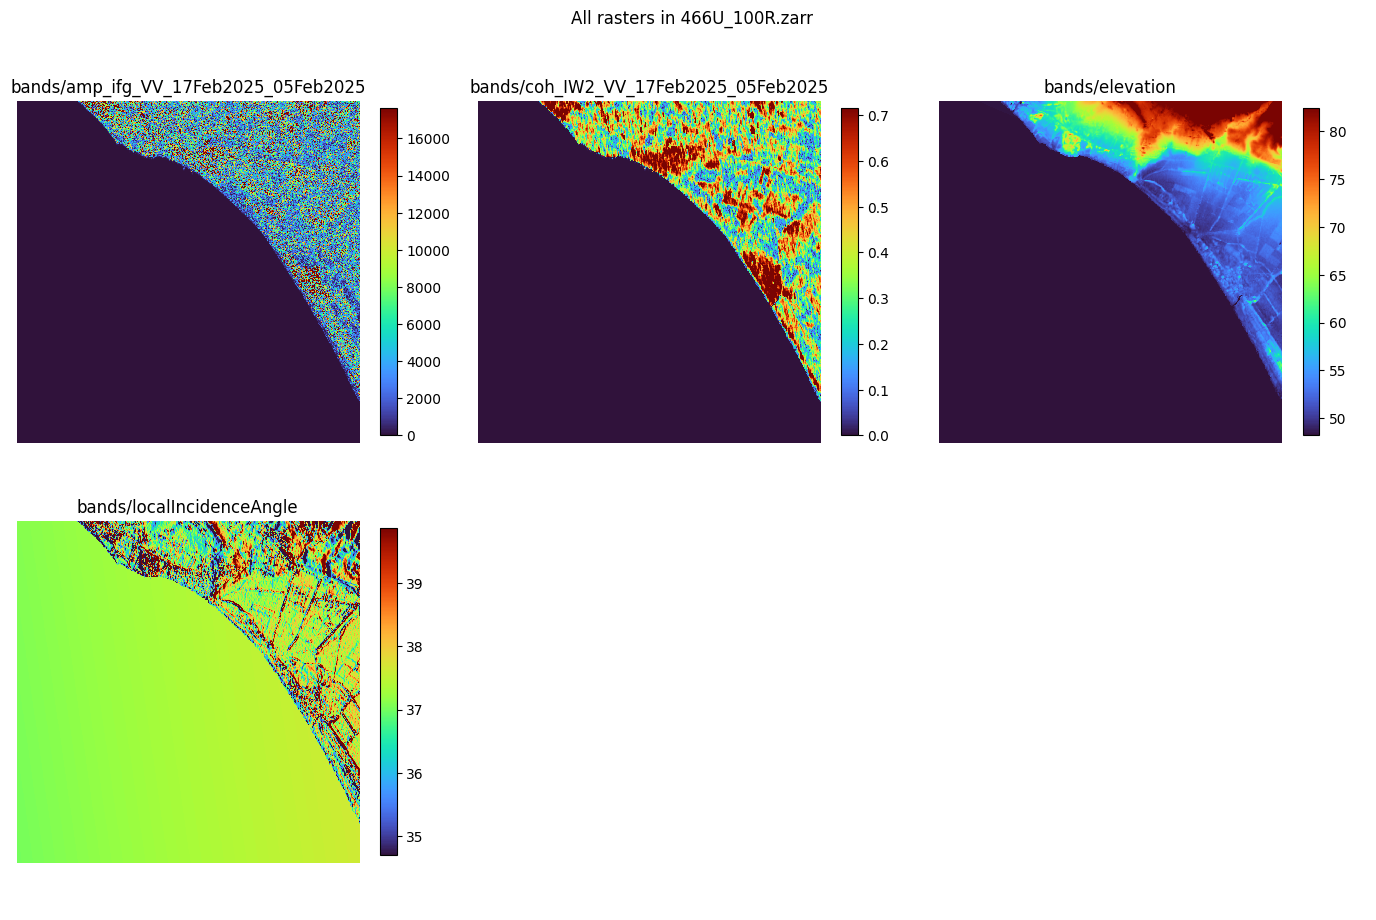

In [8]:
def as_2d(data):
    data = np.asarray(data)

    while data.ndim > 2:
        data = data[0]

    if data.ndim != 2:
        raise ValueError(f'Expected raster with 2 dims, got shape {data.shape}')

    return data


def robust_vmin_vmax(data, low=2.0, high=98.0):
    finite = np.asarray(data[np.isfinite(data)])
    if finite.size == 0:
        return 0.0, 1.0

    vmin, vmax = np.nanpercentile(finite, [low, high])

    if not np.isfinite(vmin) or not np.isfinite(vmax):
        vmin, vmax = np.nanmin(finite), np.nanmax(finite)

    if vmin == vmax:
        eps = 1.0 if vmin == 0 else abs(float(vmin)) * 1e-6
        return vmin - eps, vmax + eps

    return float(vmin), float(vmax)


def combine_iq_amplitude(rasters):
    by_name = {name: arr for name, arr in rasters}
    used = set()
    out = []

    for name, arr in rasters:
        if name in used:
            continue
        if not name.split('/')[-1].startswith('i_ifg_'):
            continue

        suffix = name.split('/')[-1][6:]
        q_name = name.rsplit('/', 1)[0] + '/' + 'q_ifg_' + suffix if '/' in name else 'q_ifg_' + suffix
        if q_name not in by_name:
            continue

        i_data = as_2d(arr[:])
        q_data = as_2d(by_name[q_name][:])
        amp = np.sqrt(np.square(i_data, dtype=np.float64) + np.square(q_data, dtype=np.float64))
        amp_name = name.replace('i_ifg_', 'amp_ifg_', 1)
        out.append((amp_name, amp))
        used.add(name)
        used.add(q_name)

    for name, arr in rasters:
        if name in used:
            continue
        out.append((name, as_2d(arr[:])))

    return out


plot_rasters = combine_iq_amplitude(raster_arrays)
n = len(plot_rasters)
n_cols = 3
n_cols = min(n_cols, n)
n_rows = math.ceil(n / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.6 * n_cols, 4.6 * n_rows))
axes = np.atleast_2d(axes).ravel()

for ax, (name, raster) in zip(axes, plot_rasters):
    vmin, vmax = robust_vmin_vmax(raster)
    im = ax.imshow(raster, cmap='turbo', interpolation='nearest', vmin=vmin, vmax=vmax)
    ax.set_title(name)
    ax.set_axis_off()
    fig.colorbar(im, ax=ax, shrink=0.75)

for ax in axes[n:]:
    ax.set_axis_off()

fig.suptitle('All rasters in 466U_100R.zarr', y=0.995)
plt.tight_layout()
plt.show()
